# Model Experiment — TimesFM (Bonus, Foundation Model)

Google's pretrained time-series foundation model, tried at a surface level per the assignment (this model is explicitly bonus, not required). Unlike every other model in this project, **no training happens here at all** -- TimesFM was already pretrained by Google on ~100 billion real-world time points (Wikipedia pageviews, Google Trends, synthetic data) and is applied **zero-shot**: it has never seen a single row of Walmart sales data, and none of its weights change based on this dataset. Logged under the `TimesFM_Evaluation` group.

## Why TimesFM, and how is "zero-shot" different from everything else?

Every other model in this project learns *from this dataset specifically*: LightGBM/XGBoost trained on engineered features, Prophet fit a small statistical model per series, DLinear/N-BEATS trained real neural network weights from random initialization using this data's gradient descent. **TimesFM does none of that.** It's a decoder-only transformer pretrained once, on a huge and completely unrelated corpus, and it forecasts by recognizing general time-series patterns (trend, seasonality, level shifts) it already learned elsewhere -- applied directly to whatever series it's handed, with zero fine-tuning.

This is the same underlying idea as how GPT-style language models get pretrained once on huge text corpora and then answer questions on topics they were never specifically trained on -- TimesFM does the equivalent for numbers instead of words.

**Practical consequence worth noting honestly:** since nothing trains on our data, there's no risk of overfitting to Walmart's specific quirks -- but also no opportunity to *learn* Walmart-specific patterns the way a from-scratch model like DLinear or N-BEATS can. This notebook is intentionally leaner than the others (no feature selection, no cross-validation, no training run) because there's genuinely nothing to select or validate against -- the model's weights are fixed before we ever load it.

## Section 1 — Imports & Setup

In [1]:
!pip install timesfm[torch] -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import timesfm
import json
import os
from tqdm import tqdm

torch.set_float32_matmul_precision("high")

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
Mounted at /content/drive


## Section 2 — Load Cleaned Data
Reads the shared cleaned dataset produced by `Data_Overview.ipynb`.

In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'

df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Loaded cleaned data:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Loaded cleaned data: (421570, 16)
0 missing values remaining


## Section 3 — Wandb Login
Authenticates this session for experiment logging.

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abali22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Confirm Clean Data (`TimesFM_Cleaning`)
Same reasoning as every other model notebook: heavy cleaning already happened once in `Data_Overview.ipynb`. This run just logs a short confirmation.

In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="TimesFM_Evaluation",
                  name="TimesFM_Cleaning", job_type="preprocessing")

wandb.log({
    "rows": df.shape[0],
    "cols": df.shape[1],
    "missing_values_total": int(df.isnull().sum().sum()),
})
wandb.config.update({"source_file": "walmart_cleaned.csv (produced by Data_Overview.ipynb)"})

wandb.finish()
print("TimesFM_Cleaning run finished")

cols,▁
missing_values_total,▁
rows,▁
cols,16
missing_values_total,0
rows,421570


TimesFM_Cleaning run finished


## Section 5 — Load the Pretrained Model
Downloads a ~800MB checkpoint from Hugging Face the first time this runs (expect a minute or two just for the download). `max_context=512` and this general config directly match Google's own official example for weekly demand forecasting -- not a guess, this is their documented use case closest to ours.

In [5]:
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(timesfm.ForecastConfig(
    max_context=512,
    max_horizon=64,       # comfortably covers both our 13-week validation and 39-week submission
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
))

print("TimesFM 2.5 loaded: 200M pretrained parameters (Google Research)")
print("No training happens in this notebook -- these weights are fixed as downloaded.")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM 2.5 loaded: 200M pretrained parameters (Google Research)
No training happens in this notebook -- these weights are fixed as downloaded.


## Section 6 — Time-Based Split
Same `2011-10-01` cutoff used in every other notebook, so results stay comparable. Since nothing trains here, this split exists purely to hold out real, known weeks to check the forecast against -- not to protect against overfitting, which isn't possible when no weights update.

In [6]:
cutoff_date = pd.Timestamp('2011-10-01')
VALIDATION_HORIZON = 13   # matches DLinear/N-BEATS's validation horizon for direct comparison
print(f"Cutoff: {cutoff_date.date()}, validation horizon: {VALIDATION_HORIZON} weeks")

Cutoff: 2011-10-01, validation horizon: 13 weeks


## Section 7 — Zero-Shot Validation Forecast (`TimesFM_Evaluation`)
No windowing or manual normalization needed -- `model.forecast()` takes each series' raw sales history directly and handles normalization internally (`normalize_inputs=True`). Batched across series for efficiency; set `MAX_SERIES` lower for a quick test run before committing to the full pass.

In [7]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

MAX_SERIES = None    # set to e.g. 50 for a quick test before running on everything
BATCH_SIZE_TFM = 256

val_inputs, val_ids, val_actuals, val_holiday = [], [], [], []
for (store, dept), group in df.groupby(['Store', 'Dept']):
    group = group.sort_values('Date')
    pre = group[group['Date'] <= cutoff_date]
    post = group[group['Date'] > cutoff_date]
    if len(pre) < 10 or len(post) < VALIDATION_HORIZON:
        continue
    val_inputs.append(pre['Weekly_Sales'].values.astype(np.float32))
    val_ids.append((store, dept))
    val_actuals.append(post['Weekly_Sales'].values[:VALIDATION_HORIZON])
    val_holiday.append(post['IsHoliday'].values[:VALIDATION_HORIZON])

if MAX_SERIES is not None:
    val_inputs, val_ids = val_inputs[:MAX_SERIES], val_ids[:MAX_SERIES]
    val_actuals, val_holiday = val_actuals[:MAX_SERIES], val_holiday[:MAX_SERIES]

print(f"Evaluating zero-shot on {len(val_inputs)} series")

run = wandb.init(project="walmart-sales-forecasting", group="TimesFM_Evaluation",
                  name="TimesFM_Evaluation", job_type="evaluation")

all_preds = []
for start in tqdm(range(0, len(val_inputs), BATCH_SIZE_TFM), desc="Zero-shot forecasting (validation)"):
    batch = val_inputs[start:start + BATCH_SIZE_TFM]
    point_forecast, _ = model.forecast(horizon=VALIDATION_HORIZON, inputs=batch)
    all_preds.append(point_forecast)

all_preds = np.clip(np.concatenate(all_preds, axis=0), a_min=0, a_max=None)

y_true_flat = np.concatenate(val_actuals)
y_pred_flat = all_preds.flatten()
holiday_flat = np.concatenate(val_holiday)

overall_wmae = wmae(y_true_flat, y_pred_flat, holiday_flat)
overall_mae = np.mean(np.abs(y_true_flat - y_pred_flat))

print(f"\nTimesFM zero-shot WMAE: {overall_wmae:.2f}")
print(f"TimesFM zero-shot MAE:  {overall_mae:.2f}")

wandb.log({"val_wmae": overall_wmae, "val_mae": overall_mae, "n_series_evaluated": len(val_inputs)})
wandb.config.update({
    "checkpoint": "google/timesfm-2.5-200m-pytorch",
    "max_context": 512, "max_horizon": 64, "validation_horizon": VALIDATION_HORIZON,
    "validation_cutoff": str(cutoff_date.date()),
})

wandb.finish()
print("TimesFM_Evaluation run finished")

Evaluating zero-shot on 2994 series


Zero-shot forecasting (validation): 100%|██████████| 12/12 [32:59<00:00, 164.97s/it]


TimesFM zero-shot WMAE: 4258.41
TimesFM zero-shot MAE:  3426.34


n_series_evaluated,▁
val_mae,▁
val_wmae,▁
n_series_evaluated,2994
val_mae,3426.33779
val_wmae,4258.40976


TimesFM_Evaluation run finished


## Section 8 — Visualize Example Forecasts (`TimesFM_Visualization`)

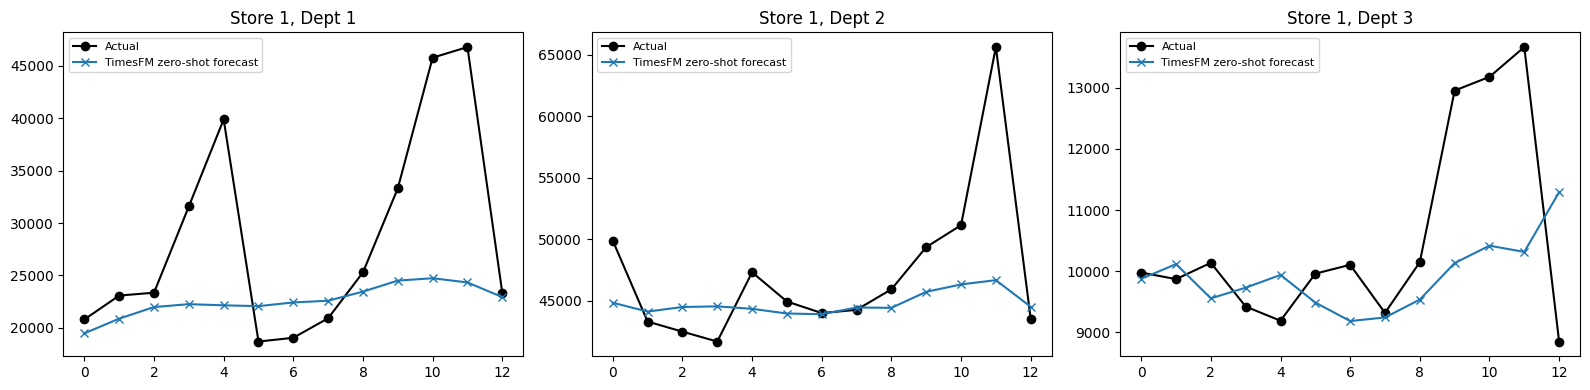

TimesFM_Visualization run finished


In [8]:
run = wandb.init(project="walmart-sales-forecasting", group="TimesFM_Evaluation",
                  name="TimesFM_Visualization", job_type="analysis")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    store, dept = val_ids[i]
    axes[i].plot(val_actuals[i], label='Actual', marker='o', color='black')
    axes[i].plot(all_preds[i], label='TimesFM zero-shot forecast', marker='x')
    axes[i].set_title(f"Store {store}, Dept {dept}")
    axes[i].legend(fontsize=8)
plt.tight_layout()
wandb.log({"Example_Forecasts": wandb.Image(fig)})
plt.show()

wandb.finish()
print("TimesFM_Visualization run finished")

## Section 9 — Real Kaggle Submission
Same zero-shot approach, applied to the real, full history and the real ~39-week test horizon in one pass -- no separate "retrain on full data" step needed here, since there was never any training to begin with. Series with too little history fall back to the overall mean, same defensive pattern used in the other notebooks' pipelines.

In [9]:
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
test_raw = pd.read_csv(raw_path + 'test.csv')
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

test_dates_sorted = sorted(test_raw['Date'].unique())
SUBMIT_HORIZON = len(test_dates_sorted)
print(f"Kaggle test set needs {SUBMIT_HORIZON} weeks forecast "
      f"({test_dates_sorted[0].date()} to {test_dates_sorted[-1].date()})")

overall_mean_fallback = df['Weekly_Sales'].mean()

submission_rows = []
series_inputs, series_keys, series_test_groups = [], [], []

for (store, dept), test_group in test_raw.groupby(['Store', 'Dept']):
    history = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    test_group = test_group.sort_values('Date')
    if len(history) >= 10:
        series_inputs.append(history['Weekly_Sales'].values.astype(np.float32))
        series_keys.append((store, dept))
        series_test_groups.append(test_group)
    else:
        for _, row in test_group.iterrows():
            submission_rows.append({'Store': store, 'Dept': dept, 'Date': row['Date'],
                                     'Weekly_Sales': overall_mean_fallback})

run = wandb.init(project="walmart-sales-forecasting", group="TimesFM_Evaluation",
                  name="TimesFM_Kaggle_Submission", job_type="submission")

all_test_preds = []
for start in tqdm(range(0, len(series_inputs), BATCH_SIZE_TFM), desc="Zero-shot forecasting (Kaggle submission)"):
    batch = series_inputs[start:start + BATCH_SIZE_TFM]
    point_forecast, _ = model.forecast(horizon=SUBMIT_HORIZON, inputs=batch)
    all_test_preds.append(point_forecast)

all_test_preds = np.clip(np.concatenate(all_test_preds, axis=0), a_min=0, a_max=None)

for i, (store, dept) in enumerate(series_keys):
    test_group = series_test_groups[i]
    preds = all_test_preds[i][:len(test_group)]
    for date, pred in zip(test_group['Date'].values, preds):
        submission_rows.append({'Store': store, 'Dept': dept, 'Date': date, 'Weekly_Sales': pred})

submission_long = pd.DataFrame(submission_rows)
submission = pd.DataFrame({
    'Id': (submission_long['Store'].astype(str) + '_' + submission_long['Dept'].astype(str) + '_' +
           pd.to_datetime(submission_long['Date']).dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': submission_long['Weekly_Sales']
})

sub_path = '/content/drive/MyDrive/ML-final/submissions/timesfm_submission.csv'
os.makedirs(os.path.dirname(sub_path), exist_ok=True)
submission.to_csv(sub_path, index=False)

print(submission.head())
print(f"\nSaved: {sub_path}")
print(f"Rows: {submission.shape[0]}")

wandb.log({"submission_rows": len(submission), "n_series_forecasted": len(series_keys)})
wandb.finish()
print("TimesFM_Kaggle_Submission run finished")

Kaggle test set needs 39 weeks forecast (2012-11-02 to 2013-07-26)


Zero-shot forecasting (Kaggle submission): 100%|██████████| 13/13 [34:13<00:00, 157.95s/it]


                Id  Weekly_Sales
0  2_77_2013-01-11  15981.258123
1  3_47_2012-11-09  15981.258123
2  3_47_2012-12-28  15981.258123
3  3_47_2013-02-15  15981.258123
4  3_47_2013-05-03  15981.258123

Saved: /content/drive/MyDrive/ML-final/submissions/timesfm_submission.csv
Rows: 115064


n_series_forecasted,▁
submission_rows,▁
n_series_forecasted,3108
submission_rows,115064


TimesFM_Kaggle_Submission run finished


## Section 10 — Save Config, Register to Model Registry
There are no trained-by-us weights to save here -- the model's parameters come entirely from the public Hugging Face checkpoint, unchanged. What gets saved and registered instead is the exact configuration (checkpoint name, context/horizon settings) that produced the winning score, for reproducibility.

In [10]:
run = wandb.init(project="walmart-sales-forecasting", group="TimesFM_Evaluation",
                  name="TimesFM_Save_Config", job_type="pipeline-export")

config_record = {
    "checkpoint": "google/timesfm-2.5-200m-pytorch",
    "max_context": 512,
    "max_horizon": 64,
    "validation_wmae": float(overall_wmae),
    "validation_cutoff": str(cutoff_date.date()),
    "note": "Zero-shot foundation model -- no weights trained on this dataset; config is the artifact.",
}
with open("/content/timesfm_config.json", "w") as f:
    json.dump(config_record, f, indent=2)

config_artifact = wandb.Artifact(
    name="timesfm_config", type="model",
    description=f"TimesFM 2.5 zero-shot config, val_wmae={overall_wmae:.2f} (no trained weights -- pretrained checkpoint used as-is)"
)
config_artifact.add_file("/content/timesfm_config.json")
wandb.run.log_artifact(config_artifact)

try:
    run.link_artifact(config_artifact, target_path="model-registry/Walmart-TimesFM-Best-Config")
    print("Linked to Model Registry as 'Walmart-TimesFM-Best-Config'")
except Exception as e:
    print("Could not auto-link to Model Registry -- link it manually in the wandb UI:", e)

wandb.finish()
print("TimesFM config saved and registered")

Could not auto-link to Model Registry -- link it manually in the wandb UI: The model registry has been migrated for teams in your organization. You may no longer make changes.


TimesFM config saved and registered


In [11]:
low_history_series = []
for (store, dept), group in test_raw.groupby(['Store', 'Dept']):
    history = df[(df['Store'] == store) & (df['Dept'] == dept)]
    if len(history) < 10:
        low_history_series.append((store, dept, len(history)))

print(f"{len(low_history_series)} series have under 10 weeks of history")
print(low_history_series[:10])

61 series have under 10 weeks of history
[(np.int64(2), np.int64(77), 2), (np.int64(3), np.int64(47), 8), (np.int64(4), np.int64(39), 1), (np.int64(5), np.int64(80), 3), (np.int64(5), np.int64(99), 0), (np.int64(8), np.int64(96), 3), (np.int64(9), np.int64(99), 0), (np.int64(10), np.int64(99), 0), (np.int64(12), np.int64(99), 1), (np.int64(14), np.int64(43), 1)]
